## Exploratory Data Analysis (EDA) of Spider Dataset

### Dataset overview

This dataset comprises a multi-center collection of lumbar spine MRI images, featuring reference segmentations for vertebrae, intervertebral discs (IVDs), and spinal canal. It includes 447 sagittal T1 and T2 MRI series derived from 218 studies involving patients with low back pain, sourced from four hospitals. An additional hidden test set is part of the SPIDER challenge. 

The overview file details MRI study assignments for training and validation, patient demographics, and scanner parameters, along with a separate file containing radiological gradings of degenerative changes.

### EDA

In [ ]:
import os
import numpy as np
import pandas as pd
import pydicom
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

In [13]:
SPIDER_IMG_DIR = "data/SPIDER/images"
SPIDER_OVERVIEW_CSV = "data/SPIDER/overview.csv"

In [14]:
overview_df = pd.read_csv(SPIDER_OVERVIEW_CSV)
overview_df = overview_df[overview_df["BodyPartExamined"] == "LSPINE"].copy()

print("SPIDER overview.csv shape:", overview_df.shape)
print("Columns:", list(overview_df.columns))

SPIDER overview.csv shape: (258, 39)
Columns: ['new_file_name', 'num_vertebrae', 'num_discs', 'sex', 'birth_date', 'subset', 'AngioFlag', 'BodyPartExamined', 'DeviceSerialNumber', 'EchoNumbers', 'EchoTime', 'EchoTrainLength', 'FlipAngle', 'ImagedNucleus', 'ImagingFrequency', 'InPlanePhaseEncodingDirection', 'MRAcquisitionType', 'MagneticFieldStrength', 'Manufacturer', 'ManufacturerModelName', 'NumberOfPhaseEncodingSteps', 'PercentPhaseFieldOfView', 'PercentSampling', 'PhotometricInterpretation', 'PixelBandwidth', 'PixelSpacing', 'RepetitionTime', 'SAR', 'SamplesPerPixel', 'ScanningSequence', 'SequenceName', 'SeriesDescription', 'SliceThickness', 'SoftwareVersions', 'SpacingBetweenSlices', 'SpecificCharacterSet', 'TransmitCoilName', 'WindowCenter', 'WindowWidth']


In [15]:
spider_records = []      # per image
genders = []
ages = []                # age in years (float), if available
num_vertebrae_list = []
num_discs_list = []
image_shapes = []        # (z, y, x)
pixel_spacings = []      # (sz, sy, sx) in mm, when available
manufacturers = []
manufacturer_model_names = []
device_serial_numbers = []

In [ ]:
def get_image_path(new_file_name):

    fname = f"{new_file_name}.mha"
    return os.path.join(SPIDER_IMG_DIR, "images", fname)


def parse_birth_date_to_age(birth_date_str):

    if pd.isna(birth_date_str) or str(birth_date_str).strip() == "":
        return None
    try:
   
        for fmt in ("%Y-%m-%d", "%d.%m.%Y", "%Y/%m/%d"):
            try:
                dob = datetime.strptime(str(birth_date_str), fmt)
                break
            except ValueError:
                dob = None
        if dob is None:
            return None
        today = datetime.today()
        age_years = (today - dob).days / 365.25
        return float(age_years)
    except Exception:
        return None

for idx, row in overview_df.iterrows():
    new_name = row["new_file_name"]          
    img_path = get_image_path(new_name)

    if not os.path.isfile(img_path):
        print(f"Missing image file for {new_name}: {img_path}")
        continue

    try:
        img = sitk.ReadImage(img_path)
    except Exception as e:
        print(f"Failed to read {img_path}: {e}")

        continue

    arr = sitk.GetArrayFromImage(img)   # (z, y, x)
    spacing = img.GetSpacing()          # (sx, sy, sz)
    sx, sy, sz = spacing
    sz_arr, sy_arr, sx_arr = arr.shape

    sex = row.get("sex", "Unknown").replace(" ", "")
    num_vertebrae = row.get("num_vertebrae", np.nan)
    num_discs = row.get("num_discs", np.nan)
    birth_date = row.get("birth_date", None)
    age_years = parse_birth_date_to_age(birth_date)
    manufacturer = row.get("Manufacturer", "Unknown")
    manufacturers.append(manufacturer)
    manufacturer_model_name = row.get("ManufacturerModelName", "Unknown")
    manufacturer_model_names.append(manufacturer_model_name)
    device_serial_number = row.get("DeviceSerialNumber", "Unknown")
    device_serial_numbers.append(device_serial_number)

    genders.append(sex if pd.notna(sex) and sex != "" else "Unknown")
    num_vertebrae_list.append(num_vertebrae)
    num_discs_list.append(num_discs)
    image_shapes.append((sz_arr, sy_arr, sx_arr))
    pixel_spacings.append((sz, sy, sx))
    ages.append(age_years)

    spider_records.append({
        "new_file_name": new_name,
        "path": img_path,
        "sex": sex,
        "age_years": age_years,
        "num_vertebrae": num_vertebrae,
        "num_discs": num_discs,
        "shape_zyx": (sz_arr, sy_arr, sx_arr),
        "spacing_xyz": (sx, sy, sz),
    })

print(f"\nTotal SPIDER images read: {len(spider_records)}")

# gender distribution
gender_counts = Counter(genders)
total_cases = sum(gender_counts.values())
print("\nSPIDER gender distribution:")
for g, c in gender_counts.items():
    frac = c / total_cases if total_cases > 0 else 0
    print(f"  {g}: {c} ({frac:.2%})")

# age statistics
valid_ages = [a for a in ages if a is not None]
if valid_ages:
    age_array = np.array(valid_ages, dtype=float)
    print("\nAge (years):")
    print(f"  Count with age: {len(valid_ages)}")
    print(f"  Mean: {age_array.mean():.1f}")
    print(f"  Std : {age_array.std(ddof=0):.1f}")
    print(f"  Min : {age_array.min():.1f}")
    print(f"  Max : {age_array.max():.1f}")
else:
    print("\nNo valid birth_date information available for age computation.")

# vertebrae / discs statistics
nv_arr = np.array([v for v in num_vertebrae_list if pd.notna(v)], dtype=float)
nd_arr = np.array([d for d in num_discs_list if pd.notna(d)], dtype=float)

if nv_arr.size > 0:
    print("\nNumber of vertebrae per case:")
    print(f"  Mean: {nv_arr.mean():.2f}")
    print(f"  Min : {nv_arr.min():.0f}")
    print(f"  Max : {nv_arr.max():.0f}")
else:
    print("\nNo num_vertebrae information available.")

if nd_arr.size > 0:
    print("\nNumber of discs per case:")
    print(f"  Mean: {nd_arr.mean():.2f}")
    print(f"  Min : {nd_arr.min():.0f}")
    print(f"  Max : {nd_arr.max():.0f}")
else:
    print("\nNo num_discs information available.")

# img shape statistics
if image_shapes:
    shapes_array = np.array(image_shapes, dtype=int)
    mean_z = shapes_array[:, 0].mean()
    mean_y = shapes_array[:, 1].mean()
    mean_x = shapes_array[:, 2].mean()
    unique_shapes = {tuple(s) for s in image_shapes}
    print("\nImage shape (z, y, x):")
    print(f"  Mean size: {mean_z:.1f} x {mean_y:.1f} x {mean_x:.1f}")
    print(f"  Unique shapes: {unique_shapes}")
else:
    print("\nNo shapes collected.")


# pixel spacing statistics in mm
valid_spacings = [ps for ps in pixel_spacings if all(v is not None for v in ps)]
if valid_spacings:
    ps_array = np.array(valid_spacings, dtype=float)   # (n, 3) [sz, sy, sx]
    mean_sz = ps_array[:, 0].mean()
    mean_sy = ps_array[:, 1].mean()
    mean_sx = ps_array[:, 2].mean()
    print("\nVoxel spacing (mm) (sz, sy, sx):")
    print(f"  Mean: {mean_sz:.4f} x {mean_sy:.4f} x {mean_sx:.4f}")
    print(f"  Unique spacings: {set(tuple(np.round(ps, 4)) for ps in ps_array)}")
    
else:
    print("\nNo valid spacing information found in SPIDER images.")


Total SPIDER images read: 258

SPIDER gender distribution:
  F: 167 (64.73%)
  M: 91 (35.27%)

No valid birth_date information available for age computation.

Number of vertebrae per case:
  Mean: 6.75
  Min : 6
  Max : 9

Number of discs per case:
  Mean: 6.75
  Min : 6
  Max : 9

Image shape (z, y, x):
  Mean size: 537.5 x 452.7 x 24.1
  Unique shapes: {(495, 448, 25), (413, 448, 26), (553, 448, 27), (392, 464, 27), (463, 559, 27), (309, 320, 15), (3682, 384, 8), (1459, 537, 36), (1677, 448, 35), (578, 448, 50), (423, 448, 25), (512, 448, 26), (424, 373, 30), (335, 448, 30), (626, 448, 28), (896, 896, 15), (550, 342, 32), (392, 448, 27), (435, 448, 25), (448, 448, 24), (406, 382, 16), (462, 448, 24), (2452, 448, 36), (393, 448, 27), (412, 448, 26), (402, 448, 26), (384, 384, 17), (462, 447, 24), (1435, 640, 32), (600, 448, 28), (1058, 1168, 41), (531, 448, 26), (383, 448, 27), (320, 320, 15), (329, 896, 23), (311, 768, 23), (478, 448, 25), (899, 448, 31), (427, 448, 25), (533, 448, 

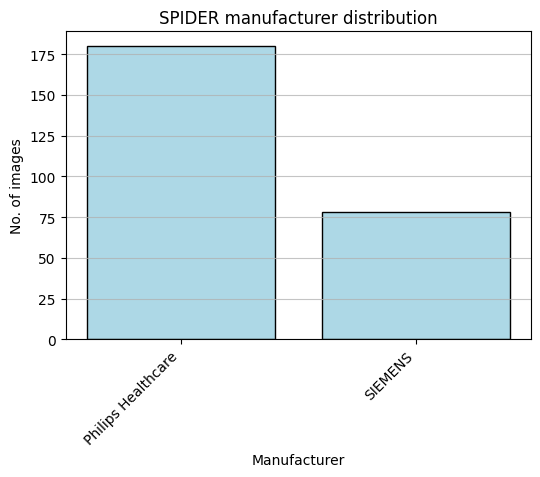

In [ ]:
# histogram of manufacturer

manufacturer_counts = Counter(manufacturers)
labels = list(manufacturer_counts.keys())
sizes = list(manufacturer_counts.values())

plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightblue', edgecolor='black')
plt.title('SPIDER manufacturer distribution')
plt.xlabel('Manufacturer')
plt.ylabel('No. of images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.show()

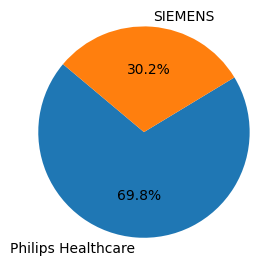

In [ ]:
# pie chart of manufacturer

labels = list(manufacturer_counts.keys())
sizes = manufacturer_counts.values()
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.axis('equal')

plt.show()

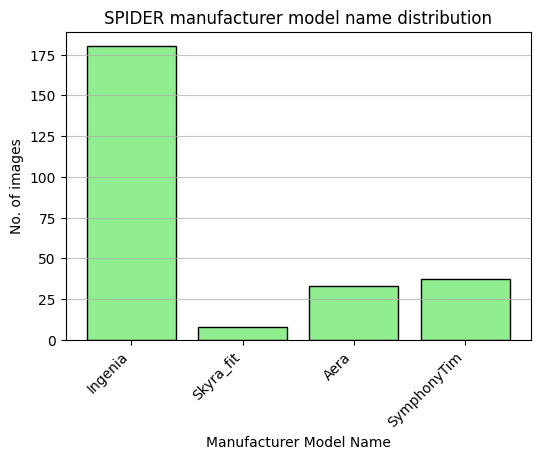

In [22]:
# histogram of manufacturer model names

model_name_counts = Counter(manufacturer_model_names)
labels = list(model_name_counts.keys())
sizes = list(model_name_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightgreen', edgecolor='black')
plt.title('SPIDER manufacturer model name distribution')
plt.xlabel('Manufacturer Model Name')
plt.ylabel('No. of images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.show()


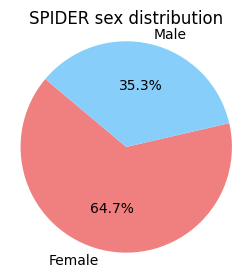

In [23]:
# sex pie chart

labels = ["Female", "Male"]
sizes = gender_counts.values()
plt.figure(figsize=(3, 3)) 
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue', 'lightgreen'])
plt.title('SPIDER sex distribution')
plt.axis('equal')

plt.show()

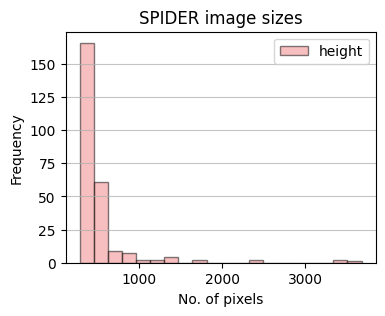

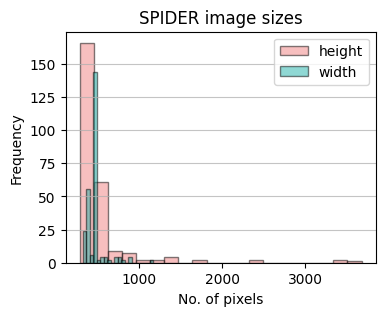

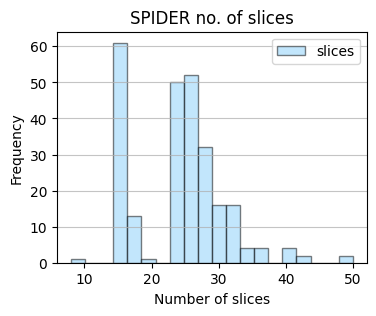

In [25]:
zs = shapes_array[:, 0]
ys = shapes_array[:, 1]
xs = shapes_array[:, 2]

# histogram of image size
shapes_array = np.array(image_shapes)
plt.figure(figsize=(4, 3))
plt.hist(zs, bins=20, alpha=0.5, label='height', color='lightcoral', edgecolor='black')
plt.title('SPIDER image sizes')
plt.xlabel('No. of pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# histogram of image size
shapes_array = np.array(image_shapes)
zs = shapes_array[:, 0]
ys = shapes_array[:, 1]
xs = shapes_array[:, 2]
plt.figure(figsize=(4, 3))
plt.hist(zs, bins=20, alpha=0.5, label='height', color='lightcoral', edgecolor='black')
plt.hist(ys, bins=20, alpha=0.5, label='width', color='lightseagreen', edgecolor='black')
plt.title('SPIDER image sizes')
plt.xlabel('No. of pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# histogram of image size
shapes_array = np.array(image_shapes)
zs = shapes_array[:, 0]
ys = shapes_array[:, 1]
xs = shapes_array[:, 2]
plt.figure(figsize=(4, 3))
plt.hist(xs, bins=20, alpha=0.5     , label='slices', color='lightskyblue', edgecolor='black')
plt.title('SPIDER no. of slices')
plt.xlabel('Number of slices')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

### MHA visualization (slices analysis)

Array shape: (797, 492, 21)


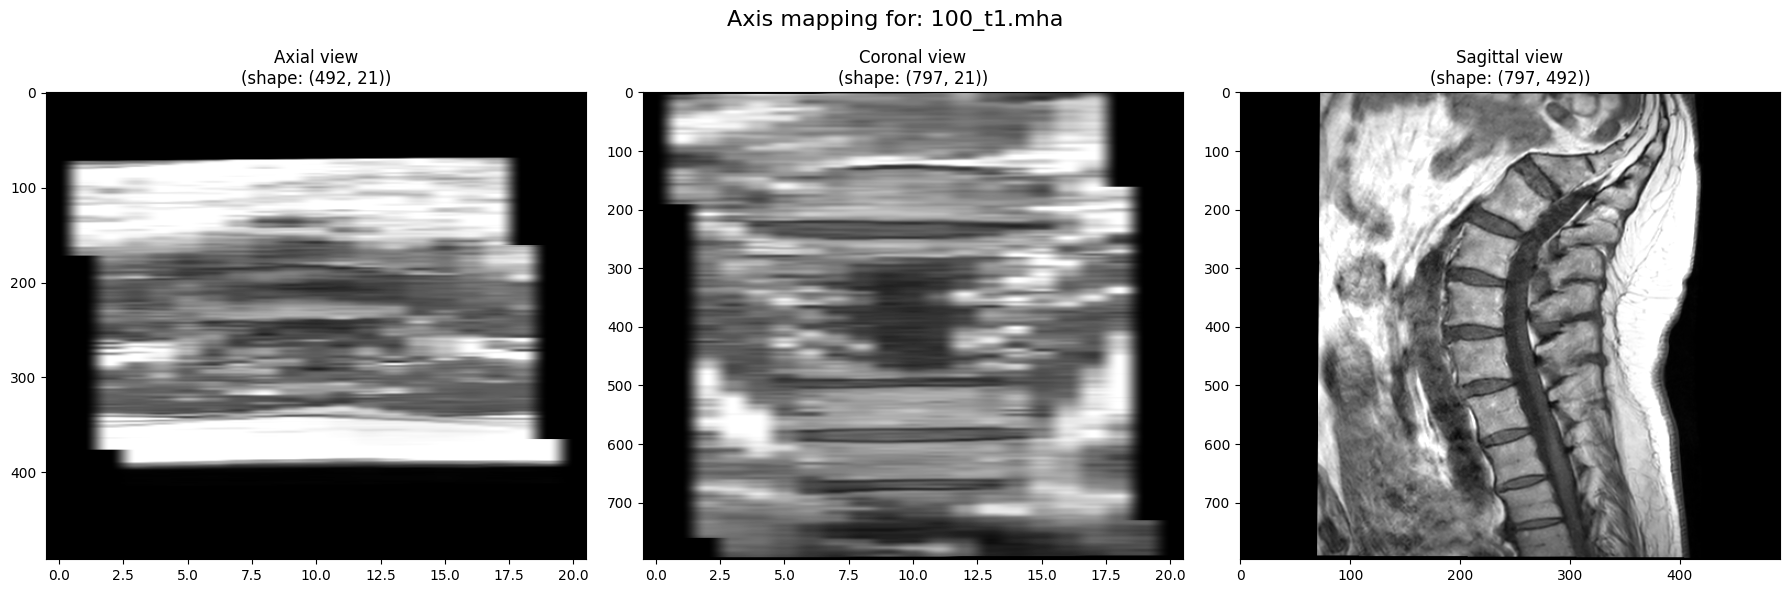

In [29]:
SPIDER_IMG_DIR = "data/SPIDER/images/images" 
files = [f for f in os.listdir(SPIDER_IMG_DIR) if f.endswith('.mha')]


if not files:
    print("There are no .mha files in the directory.")
else:
    example_filename = files[0] 
    example_path = os.path.join(SPIDER_IMG_DIR, example_filename)
    
    
    img = sitk.ReadImage(example_path)
    arr = sitk.GetArrayFromImage(img) # (Z, Y, X) --> In SPIDER it is (Height, Width, Slices) or (Slices, Height, Width), we'll observe it
    
    print(f"Array shape: {arr.shape}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    

    # slice 1 -- axial
    slice_axial = arr[mid_0, :, :]
    axes[0].imshow(slice_axial, cmap='gray', aspect='auto') 
    axes[0].set_title(f"Axial view\n(shape: {slice_axial.shape})")

    # slice 2 -- coronal
    axes[1].imshow(arr[:, mid_1, :], cmap='gray', aspect='auto')
    axes[1].set_title(f"Coronal view\n(shape: {arr[:, mid_1, :].shape})")
    # slice 3 -- sagittal
    axes[2].imshow(arr[:, :, mid_2], cmap='gray', aspect='auto')
    axes[2].set_title(f"Sagittal view\n(shape: {arr[:, :, mid_2].shape})")
    
    plt.suptitle(f"Axis mapping for: {example_filename}", fontsize=16)
    plt.tight_layout()
    plt.show()


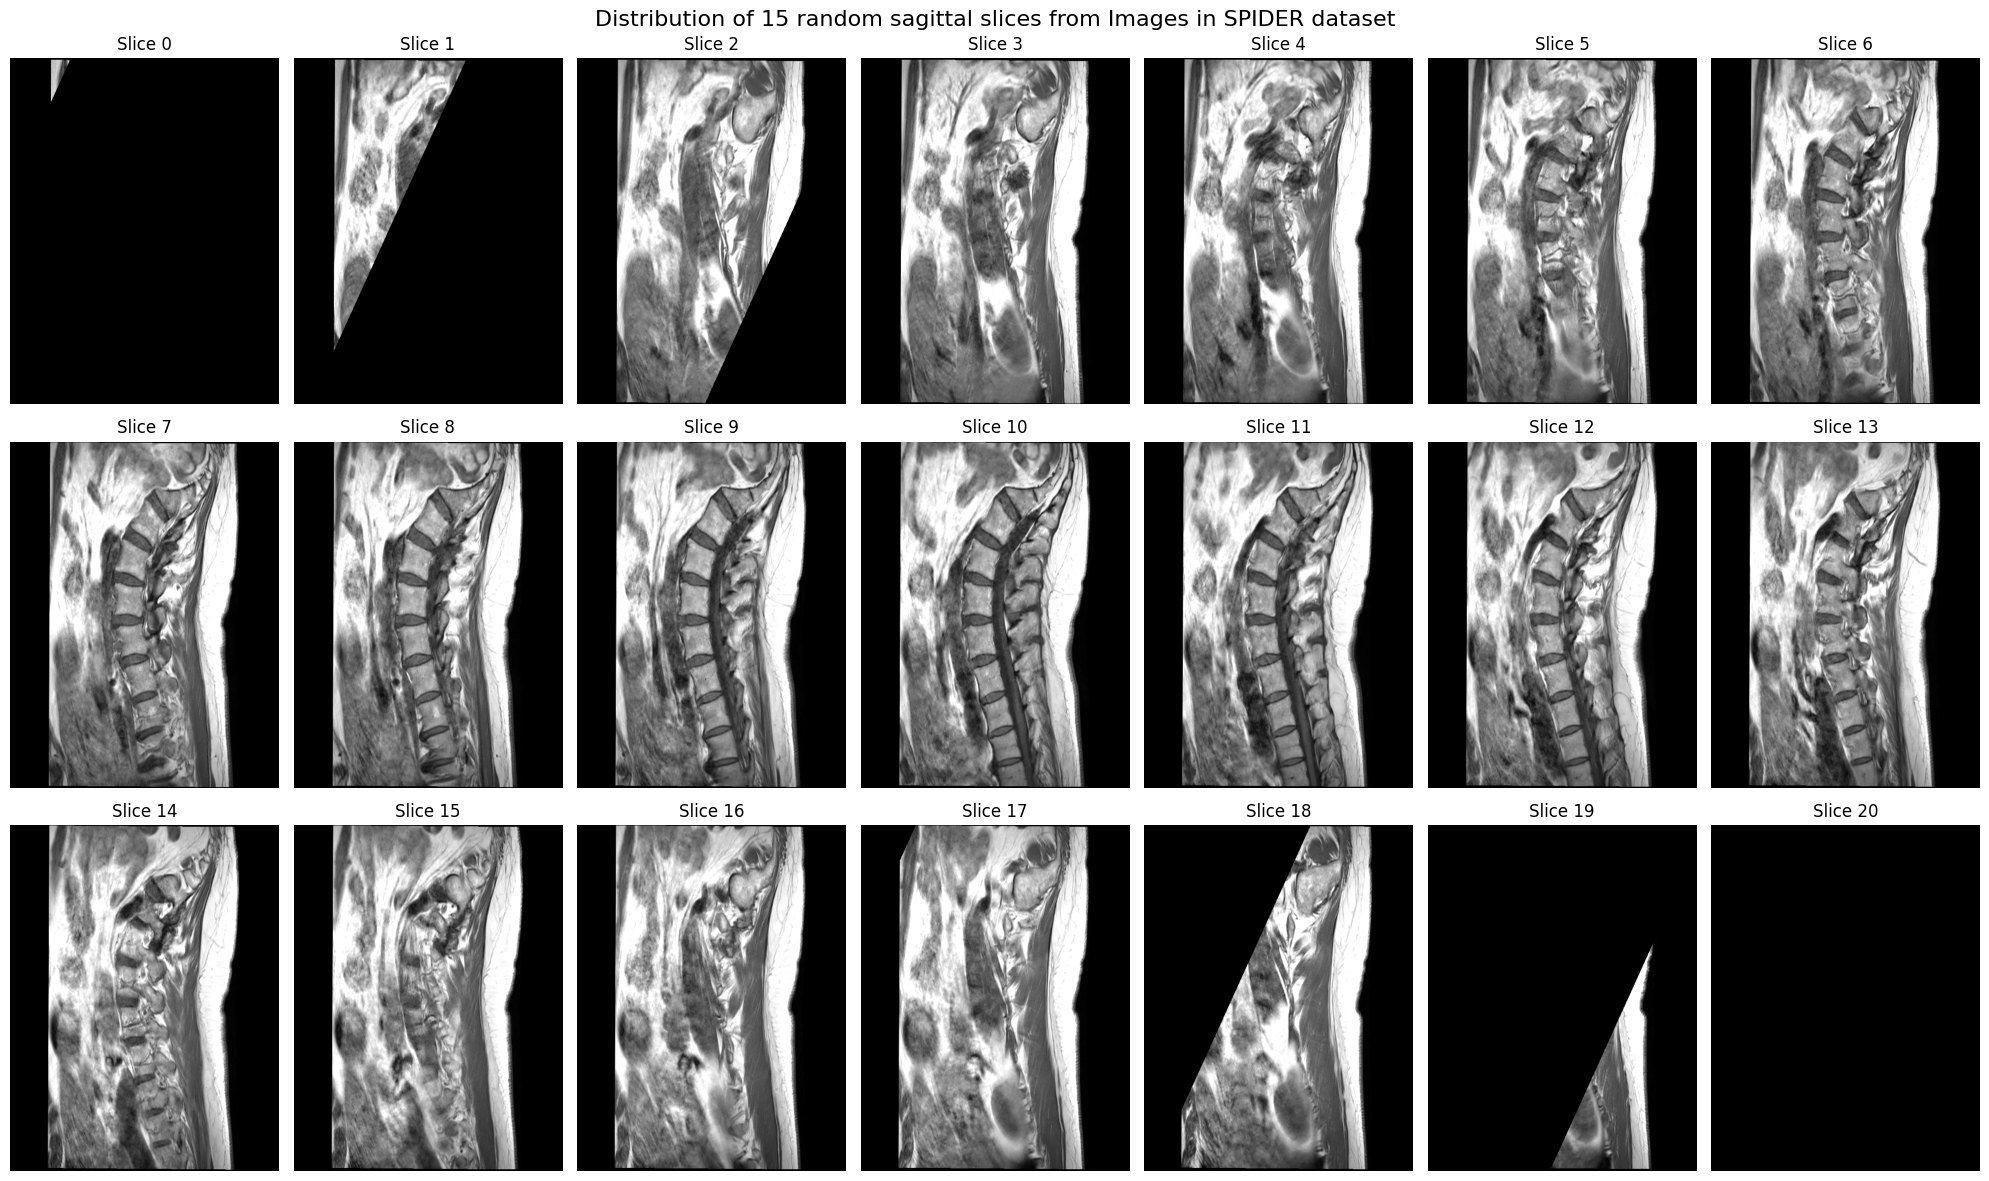

In [48]:
slice_axis = np.argmin(arr.shape)
num_slices = arr.shape[slice_axis]
    

cols = 7
rows = math.ceil(num_slices / cols)
    
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()
    
for i in range(len(axes)):
    if i < num_slices:
           
        if slice_axis == 0:
                slice_img = arr[i, :, :]
        elif slice_axis == 1:
                slice_img = arr[:, i, :]
        else: 
                slice_img = arr[:, :, i]
            
        axes[i].imshow(slice_img, cmap='gray', aspect='auto')
        axes[i].set_title(f"Slice {i}")
        axes[i].axis('off')
    else:
        axes[i].axis('off') 

plt.suptitle(f"Distribution of 15 random sagittal slices from Images in SPIDER dataset", fontsize=16)
plt.tight_layout()
plt.show()